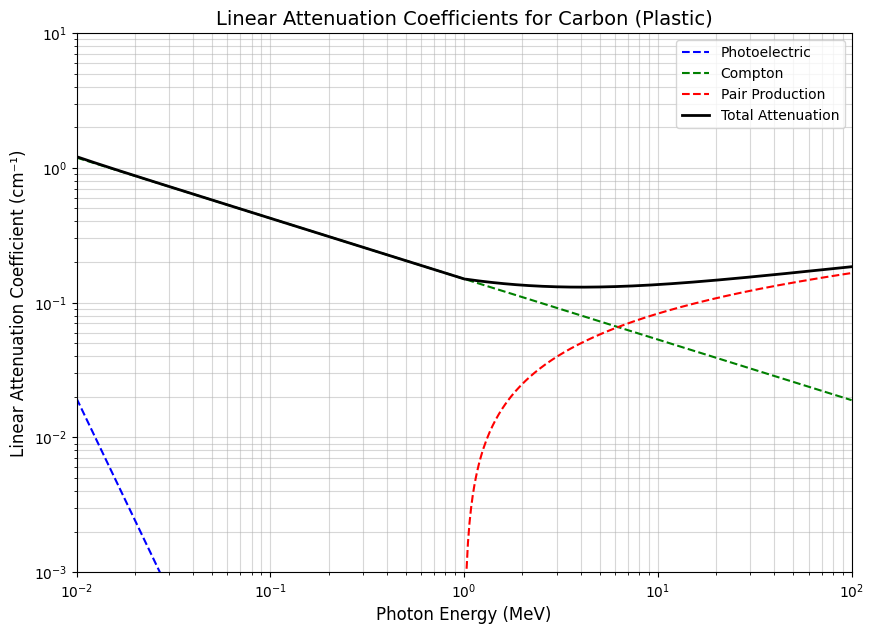

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Energy range from 0.01 MeV to 100 MeV
energies = np.logspace(-2, 2, 500)

# Physical Constants/Scaling for Carbon (Z=6, density ~2.26 g/cm3 for graphite)
# Note: For plastic, density would be ~1.0, but we'll use Z=6 characteristics.
rho = 1.0  # Normalized to 1 g/cm3 for typical plastic

# 1. Photoelectric Effect (Approx: scales with Z^4 / E^3)
# Dominant at very low energies
mu_pe = 0.015 * (6**4 / (energies * 1000)**3) * rho

# 2. Compton Scattering (Klein-Nishina approximation simplified)
# Dominant for Carbon from ~20keV to ~20MeV
mu_compton = 0.15 * (energies**-0.45) * rho

# 3. Pair Production (Threshold at 1.022 MeV)
mu_pair = np.where(energies > 1.022, 0.001 * (6**2) * np.log(energies), 0)

# Total Attenuation
mu_total = mu_pe + mu_compton + mu_pair

# Plotting
plt.figure(figsize=(10, 7))
plt.loglog(energies, mu_pe, '--', label='Photoelectric', color='blue')

plt.loglog(energies, mu_compton, '--', label='Compton', color='green')
plt.loglog(energies, mu_pair, '--', label='Pair Production', color='red')
plt.loglog(energies, mu_total, '-', label='Total Attenuation', color='black', linewidth=2)

plt.title('Linear Attenuation Coefficients for Carbon (Plastic)', fontsize=14)
plt.xlabel('Photon Energy (MeV)', fontsize=12)
plt.ylabel('Linear Attenuation Coefficient (cm⁻¹)', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.ylim(0.001, 10)
plt.xlim(0.01, 100)

plt.show()

Calculating gamma ray range in PLASTIC:
  Z = 6, A = 12, ρ = 1.0 g/cm³


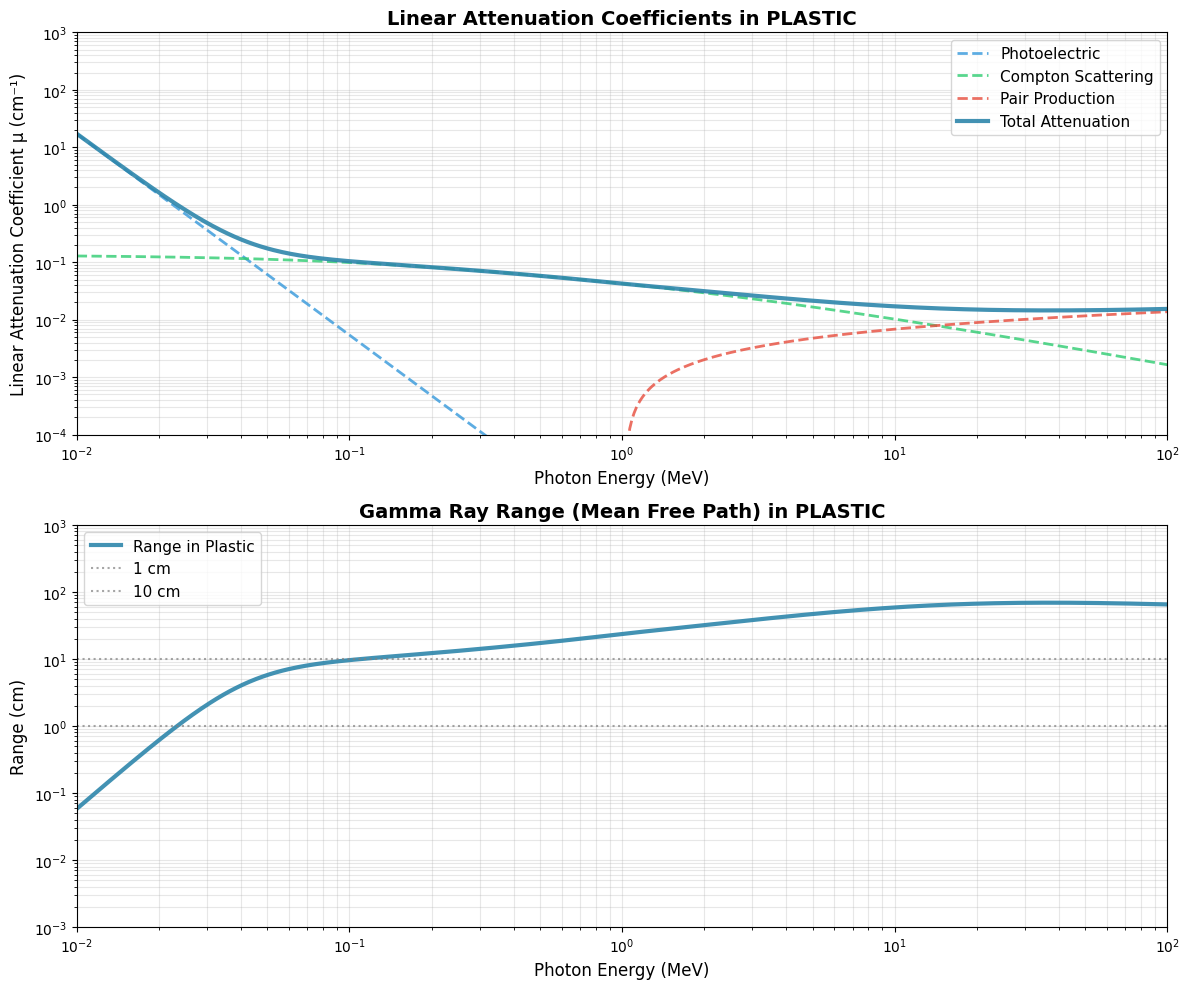


Gamma ray range in plastic at key energies:
--------------------------------------------------
   0.1 MeV: μ = 0.104 cm⁻¹  →  Range = 9.62 cm
   0.5 MeV: μ = 0.058 cm⁻¹  →  Range = 17.26 cm
   1.0 MeV: μ = 0.043 cm⁻¹  →  Range = 23.52 cm
   6.0 MeV: μ = 0.020 cm⁻¹  →  Range = 50.17 cm

💡 Range Definition:
   Range = Mean Free Path = 1/μ (distance for 1/e = 63% attenuation)

💡 To change material, modify 'element' variable:
   Available materials: ['plastic', 'aluminum', 'iron', 'lead', 'concrete', 'water']
   Current material: 'plastic'


In [3]:
# ===================================================================
# GAMMA RAY RANGE IN MATERIALS
# ===================================================================

"""
Calculate and plot gamma ray range in different materials.
Range for photons is defined by the mean free path (1/μ).
"""

import numpy as np
import matplotlib.pyplot as plt

# Material properties database
MATERIALS = {
    'plastic': {'Z': 6, 'A': 12, 'density': 1.0, 'color': '#2E86AB'},     # Typical organic plastic
    'aluminum': {'Z': 13, 'A': 27, 'density': 2.70, 'color': '#A23B72'},  # Al metal
    'iron': {'Z': 26, 'A': 56, 'density': 7.87, 'color': '#F18F01'},      # Fe metal
    'lead': {'Z': 82, 'A': 207, 'density': 11.34, 'color': '#C73E1D'},    # Pb metal
    'concrete': {'Z': 11, 'A': 22, 'density': 2.3, 'color': '#8E44AD'},   # Typical concrete
    'water': {'Z': 7.4, 'A': 14.9, 'density': 1.0, 'color': '#27AE60'}   # H2O effective Z
}

# Select material (change this variable to plot different materials!)
element = 'plastic'  # Change this: 'plastic', 'aluminum', 'iron', 'lead', 'concrete', 'water'

def calculate_attenuation_coefficient(energies_mev, material_props):
    """
    Calculate linear attenuation coefficient for photons in material.
    
    Parameters:
    energies_mev: Photon energies in MeV
    material_props: Dictionary with Z, A, density
    
    Returns:
    mu_total: Linear attenuation coefficient (cm⁻¹)
    """
    # Ensure input is numpy array
    energies_mev = np.asarray(energies_mev)
    
    Z = material_props['Z']
    A = material_props['A'] 
    rho = material_props['density']
    
    # Convert to keV for some calculations
    energies_kev = energies_mev * 1000
    
    # 1. Photoelectric Effect: σ ∝ Z⁴/E³·⁵ (dominant at low energies)
    # Empirical formula with proper scaling
    mu_pe = (0.5 * Z**4 * rho) / (A * energies_kev**3.5) * 1000
    
    # 2. Compton Scattering: Klein-Nishina formula (simplified)
    # Less Z-dependent, dominant at intermediate energies
    alpha = energies_kev / 511  # E/m_e*c²
    klein_nishina = (1 + alpha) / alpha**2 * ((2*(1+alpha))/(1+2*alpha) - np.log(1+2*alpha)/alpha) + np.log(1+2*alpha)/(2*alpha) - (1+3*alpha)/(1+2*alpha)**2
    mu_compton = 0.2 * Z * rho / A * klein_nishina
    
    # 3. Pair Production: σ ∝ Z² (threshold at 1.022 MeV)
    # Only above threshold energy
    threshold_mask = energies_mev > 1.022
    mu_pair = np.zeros_like(energies_mev)
    mu_pair[threshold_mask] = (0.001 * Z**2 * rho / A * 
                              np.log(energies_mev[threshold_mask] / 1.022))
    
    # Total attenuation coefficient
    mu_total = mu_pe + mu_compton + mu_pair
    
    return mu_total, mu_pe, mu_compton, mu_pair

def calculate_gamma_range(mu_total):
    """
    Calculate gamma ray range (mean free path) from attenuation coefficient.
    
    Parameters:
    mu_total: Linear attenuation coefficient (cm⁻¹)
    
    Returns:
    range_cm: Gamma ray range in cm (mean free path)
    """
    
    # Avoid division by zero
    mu_safe = np.maximum(mu_total, 1e-10)
    
    # Range is mean free path: λ = 1/μ
    range_cm = 1.0 / mu_safe
    
    return range_cm

# Energy range from 10 keV to 100 MeV  
energies = np.logspace(-2, 2, 500)  # MeV

# Get material properties
mat_props = MATERIALS[element]
print(f"Calculating gamma ray range in {element.upper()}:")
print(f"  Z = {mat_props['Z']}, A = {mat_props['A']}, ρ = {mat_props['density']} g/cm³")

# Calculate attenuation coefficients
mu_total, mu_pe, mu_compton, mu_pair = calculate_attenuation_coefficient(energies, mat_props)

# Calculate gamma ray range
gamma_range = calculate_gamma_range(mu_total)

# Create dual plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Attenuation coefficients (same as before)
ax1.loglog(energies, mu_pe, '--', label='Photoelectric', color='#3498DB', linewidth=2, alpha=0.8)
ax1.loglog(energies, mu_compton, '--', label='Compton Scattering', color='#2ECC71', linewidth=2, alpha=0.8)
ax1.loglog(energies, mu_pair, '--', label='Pair Production', color='#E74C3C', linewidth=2, alpha=0.8)
ax1.loglog(energies, mu_total, '-', label='Total Attenuation', 
          color=mat_props['color'], linewidth=3, alpha=0.9)

ax1.set_title(f'Linear Attenuation Coefficients in {element.upper()}', fontsize=14, fontweight='bold')
ax1.set_xlabel('Photon Energy (MeV)', fontsize=12)
ax1.set_ylabel('Linear Attenuation Coefficient μ (cm⁻¹)', fontsize=12)
ax1.grid(True, which="both", ls="-", alpha=0.3)
ax1.legend(fontsize=11)
ax1.set_ylim(0.0001, 1000)
ax1.set_xlim(0.01, 100)

# Plot 2: Gamma ray range (NEW!)
ax2.loglog(energies, gamma_range, '-', label=f'Range in {element.title()}', 
          color=mat_props['color'], linewidth=3, alpha=0.9)

ax2.set_title(f'Gamma Ray Range (Mean Free Path) in {element.upper()}', fontsize=14, fontweight='bold')
ax2.set_xlabel('Photon Energy (MeV)', fontsize=12)
ax2.set_ylabel('Range (cm)', fontsize=12)
ax2.grid(True, which="both", ls="-", alpha=0.3)
ax2.legend(fontsize=11)
ax2.set_ylim(0.001, 1000)
ax2.set_xlim(0.01, 100)

# Add some reference lines for context
ax2.axhline(y=1, color='gray', linestyle=':', alpha=0.7, label='1 cm')
ax2.axhline(y=10, color='gray', linestyle=':', alpha=0.7, label='10 cm') 
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

# Print some example values
print(f"\nGamma ray range in {element} at key energies:")
print("-" * 50)
example_energies = [0.1, 0.5, 1.0, 6.0]  # MeV

for energy in example_energies:
    idx = np.argmin(np.abs(energies - energy))
    print(f"  {energy:4.1f} MeV: μ = {mu_total[idx]:.3f} cm⁻¹  →  Range = {gamma_range[idx]:.2f} cm")

print(f"\n💡 Range Definition:")
print(f"   Range = Mean Free Path = 1/μ (distance for 1/e = 63% attenuation)")
print(f"\n💡 To change material, modify 'element' variable:")
print(f"   Available materials: {list(MATERIALS.keys())}")
print(f"   Current material: '{element}'")

MATERIAL COMPARISON FOR GAMMA RAY SHIELDING


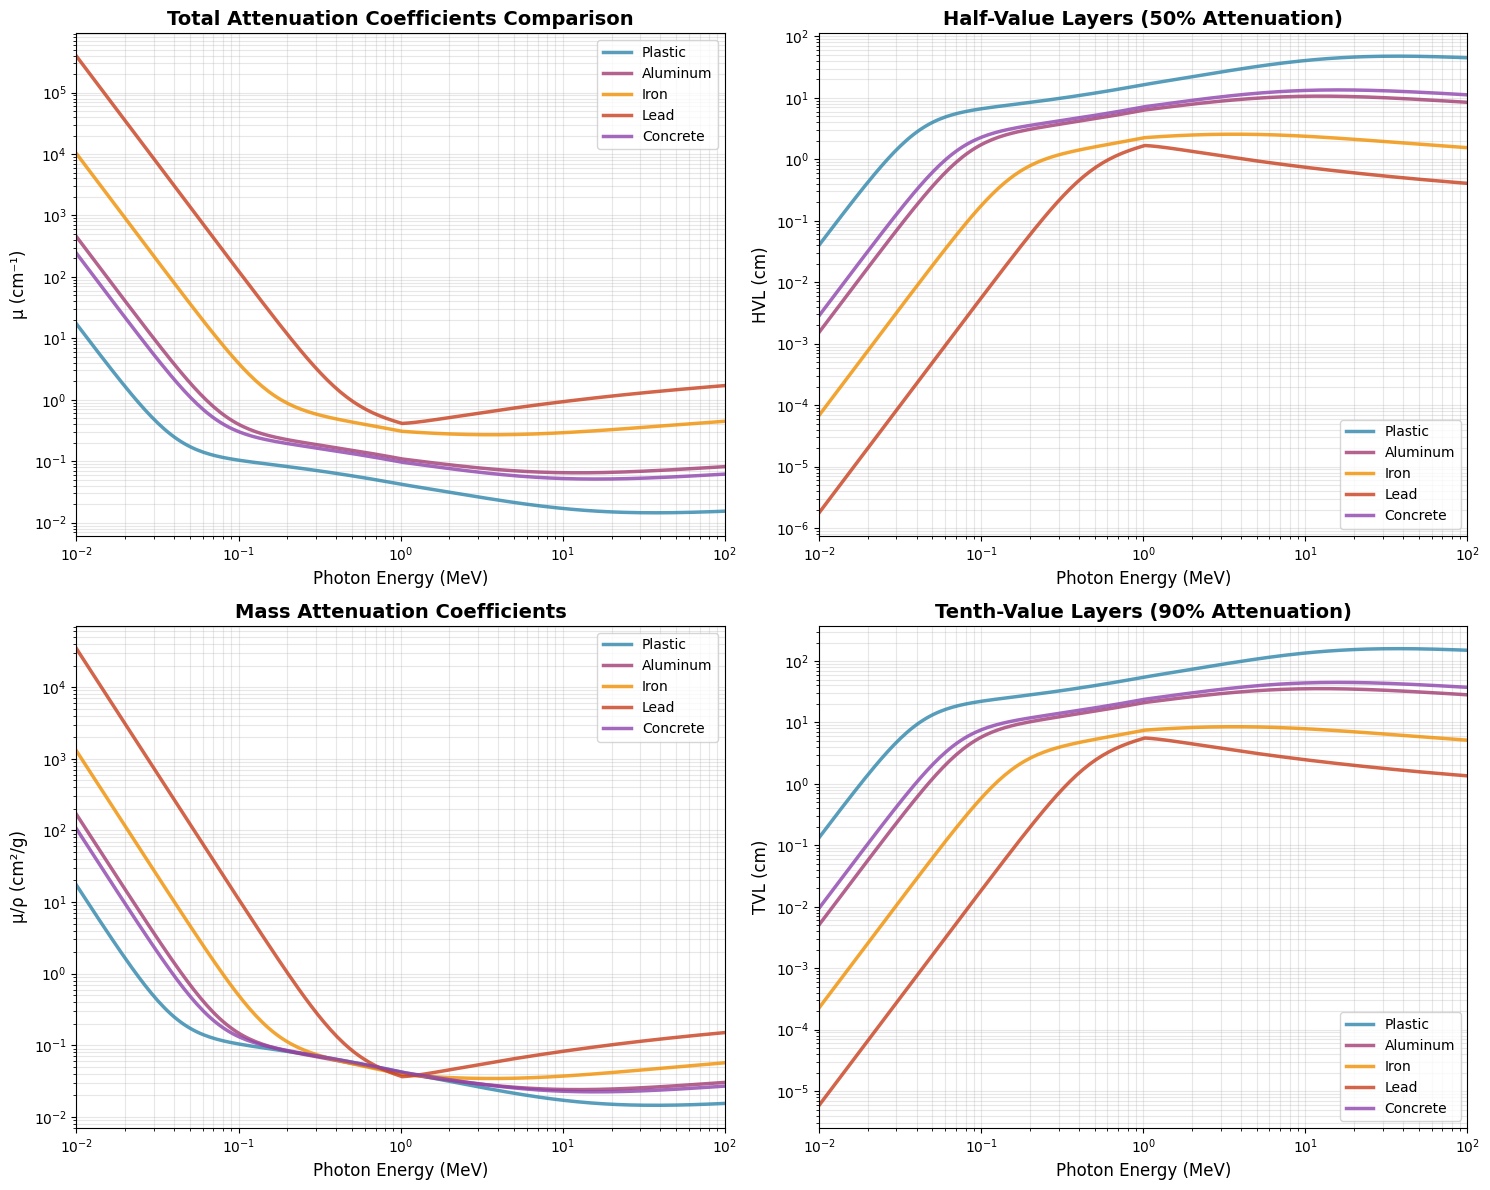


QUANTITATIVE COMPARISON AT KEY GAMMA ENERGIES:

🔹 0.1 MeV photons:
Material     μ (cm⁻¹)     HVL (cm)     TVL (cm)    
--------------------------------------------------
Plastic      0.104        6.65         22.11       
Aluminum     0.400        1.73         5.76        
Iron         3.933        0.18         0.59        
Lead         124.729      0.01         0.02        
Concrete     0.304        2.28         7.58        

🔹 0.5 MeV photons:
Material     μ (cm⁻¹)     HVL (cm)     TVL (cm)    
--------------------------------------------------
Plastic      0.058        11.96        39.72       
Aluminum     0.151        4.58         15.23       
Iron         0.435        1.59         5.29        
Lead         0.964        0.72         2.39        
Concrete     0.134        5.19         17.24       

🔹 1.0 MeV photons:
Material     μ (cm⁻¹)     HVL (cm)     TVL (cm)    
--------------------------------------------------
Plastic      0.042        16.37        54.39       
Aluminum   

In [4]:
# ===================================================================
# MATERIAL COMPARISON FOR GAMMA SHIELDING
# ===================================================================

"""
Compare gamma ray attenuation and range parameters across different materials.
Useful for selecting optimal shielding materials for different energies.
"""

import numpy as np
import matplotlib.pyplot as plt

# Material properties database (redefined for this cell)
MATERIALS = {
    'plastic': {'Z': 6, 'A': 12, 'density': 1.0, 'color': '#2E86AB'},     # Typical organic plastic
    'aluminum': {'Z': 13, 'A': 27, 'density': 2.70, 'color': '#A23B72'},  # Al metal
    'iron': {'Z': 26, 'A': 56, 'density': 7.87, 'color': '#F18F01'},      # Fe metal
    'lead': {'Z': 82, 'A': 207, 'density': 11.34, 'color': '#C73E1D'},    # Pb metal
    'concrete': {'Z': 11, 'A': 22, 'density': 2.3, 'color': '#8E44AD'},   # Typical concrete
    'water': {'Z': 7.4, 'A': 14.9, 'density': 1.0, 'color': '#27AE60'}   # H2O effective Z
}

def calculate_attenuation_coefficient(energies_mev, material_props):
    """
    Calculate linear attenuation coefficient for photons in material.
    """
    # Ensure input is numpy array
    energies_mev = np.asarray(energies_mev)
    
    Z = material_props['Z']
    A = material_props['A'] 
    rho = material_props['density']
    
    # Convert to keV for some calculations
    energies_kev = energies_mev * 1000
    
    # 1. Photoelectric Effect: σ ∝ Z⁴/E³·⁵ (dominant at low energies)
    mu_pe = (0.5 * Z**4 * rho) / (A * energies_kev**3.5) * 1000
    
    # 2. Compton Scattering: Klein-Nishina formula (simplified)
    alpha = energies_kev / 511  # E/m_e*c²
    klein_nishina = (1 + alpha) / alpha**2 * ((2*(1+alpha))/(1+2*alpha) - np.log(1+2*alpha)/alpha) + np.log(1+2*alpha)/(2*alpha) - (1+3*alpha)/(1+2*alpha)**2
    mu_compton = 0.2 * Z * rho / A * klein_nishina
    
    # 3. Pair Production: σ ∝ Z² (threshold at 1.022 MeV)
    threshold_mask = energies_mev > 1.022
    mu_pair = np.zeros_like(energies_mev)
    mu_pair[threshold_mask] = (0.001 * Z**2 * rho / A * 
                              np.log(energies_mev[threshold_mask] / 1.022))
    
    # Total attenuation coefficient
    mu_total = mu_pe + mu_compton + mu_pair
    
    return mu_total, mu_pe, mu_compton, mu_pair

def calculate_range_parameters(mu_total):
    """
    Calculate various range parameters from attenuation coefficient.
    """
    # Avoid division by zero
    mu_safe = np.maximum(mu_total, 1e-10)
    
    ranges = {
        'mean_free_path': 1.0 / mu_safe,                    # λ = 1/μ (1/e attenuation)
        'half_value_layer': np.log(2) / mu_safe,           # HVL (50% attenuation) 
        'tenth_value_layer': np.log(10) / mu_safe,         # TVL (90% attenuation)
        'quarter_value_layer': np.log(4) / mu_safe,        # QVL (75% attenuation)
        'relaxation_length': 1.0 / mu_safe                 # Same as mean free path
    }
    
    return ranges

# Select materials for comparison
comparison_materials = ['plastic', 'aluminum', 'iron', 'lead', 'concrete']

# Energy range
energies_comp = np.logspace(-2, 2, 200)  # 10 keV to 100 MeV

# Calculate attenuation coefficients for all materials
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

print("MATERIAL COMPARISON FOR GAMMA RAY SHIELDING")
print("="*60)

# Plot 1: Total attenuation coefficients comparison
for material in comparison_materials:
    mat_props = MATERIALS[material]
    mu_total, _, _, _ = calculate_attenuation_coefficient(energies_comp, mat_props)
    
    ax1.loglog(energies_comp, mu_total, '-', label=f'{material.title()}', 
              color=mat_props['color'], linewidth=2.5, alpha=0.8)

ax1.set_title('Total Attenuation Coefficients Comparison', fontsize=14, fontweight='bold')
ax1.set_xlabel('Photon Energy (MeV)', fontsize=12)
ax1.set_ylabel('μ (cm⁻¹)', fontsize=12)
ax1.grid(True, which="both", ls="-", alpha=0.3)
ax1.legend()
ax1.set_xlim(0.01, 100)

# Plot 2: Half-value layers comparison
for material in comparison_materials:
    mat_props = MATERIALS[material]
    mu_total, _, _, _ = calculate_attenuation_coefficient(energies_comp, mat_props)
    ranges = calculate_range_parameters(mu_total)
    
    ax2.loglog(energies_comp, ranges['half_value_layer'], '-', label=f'{material.title()}',
              color=mat_props['color'], linewidth=2.5, alpha=0.8)

ax2.set_title('Half-Value Layers (50% Attenuation)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Photon Energy (MeV)', fontsize=12)
ax2.set_ylabel('HVL (cm)', fontsize=12)
ax2.grid(True, which="both", ls="-", alpha=0.3)
ax2.legend()
ax2.set_xlim(0.01, 100)

# Plot 3: Mass attenuation coefficients (μ/ρ)
for material in comparison_materials:
    mat_props = MATERIALS[material]
    mu_total, _, _, _ = calculate_attenuation_coefficient(energies_comp, mat_props)
    mu_mass = mu_total / mat_props['density']  # cm²/g
    
    ax3.loglog(energies_comp, mu_mass, '-', label=f'{material.title()}',
              color=mat_props['color'], linewidth=2.5, alpha=0.8)

ax3.set_title('Mass Attenuation Coefficients', fontsize=14, fontweight='bold')
ax3.set_xlabel('Photon Energy (MeV)', fontsize=12)
ax3.set_ylabel('μ/ρ (cm²/g)', fontsize=12)
ax3.grid(True, which="both", ls="-", alpha=0.3)
ax3.legend()
ax3.set_xlim(0.01, 100)

# Plot 4: Thickness for 90% attenuation (TVL)
for material in comparison_materials:
    mat_props = MATERIALS[material]
    mu_total, _, _, _ = calculate_attenuation_coefficient(energies_comp, mat_props)
    ranges = calculate_range_parameters(mu_total)
    
    ax4.loglog(energies_comp, ranges['tenth_value_layer'], '-', label=f'{material.title()}',
              color=mat_props['color'], linewidth=2.5, alpha=0.8)

ax4.set_title('Tenth-Value Layers (90% Attenuation)', fontsize=14, fontweight='bold')
ax4.set_xlabel('Photon Energy (MeV)', fontsize=12)
ax4.set_ylabel('TVL (cm)', fontsize=12)
ax4.grid(True, which="both", ls="-", alpha=0.3)
ax4.legend()
ax4.set_xlim(0.01, 100)

plt.tight_layout()
plt.show()

# Print quantitative comparison at key energies
key_energies = [0.1, 0.5, 1.0, 6.0]  # MeV
print(f"\nQUANTITATIVE COMPARISON AT KEY GAMMA ENERGIES:")
print("="*60)

for energy in key_energies:
    print(f"\n🔹 {energy} MeV photons:")
    print(f"{'Material':<12} {'μ (cm⁻¹)':<12} {'HVL (cm)':<12} {'TVL (cm)':<12}")
    print("-" * 50)
    
    for material in comparison_materials:
        mat_props = MATERIALS[material]
        mu_total, _, _, _ = calculate_attenuation_coefficient([energy], mat_props)
        ranges = calculate_range_parameters(mu_total)
        
        print(f"{material.title():<12} {mu_total[0]:<12.3f} {ranges['half_value_layer'][0]:<12.2f} {ranges['tenth_value_layer'][0]:<12.2f}")

print(f"\n🎯 SHIELDING EFFECTIVENESS SUMMARY:")
print("="*60)
print("• LEAD: Highest Z → best for low energy gammas (< 1 MeV)")
print("• IRON: Good intermediate shielding, mechanically strong") 
print("• ALUMINUM: Lightweight, good for high energy gammas")
print("• CONCRETE: Cheap, bulky, good neutron moderator too")
print("• PLASTIC: Light, poor gamma shield, good neutron moderator")

print(f"\n💡 DESIGN GUIDELINES:")
print("• Low energy (< 100 keV): Lead dominates due to photoelectric effect")
print("• Medium energy (0.1-10 MeV): Lead still best, but gap narrows") 
print("• High energy (> 10 MeV): Differences smaller, weight becomes factor")
print("• Mixed radiation: Consider neutron moderation + gamma shielding")

In [7]:
# propabilities of interactions for a photon at 4.4 MeV in plastic, in percentages
energy_mev = 4.4
mat_props = MATERIALS['plastic']
mu_total, mu_pe, mu_compton, mu_pair = calculate_attenuation_coefficient([energy_mev], mat_props)
print(f"\nAt {energy_mev} MeV in PLASTIC:")
print(f"  Total Attenuation Coefficient (μ): {mu_total[0]:.3f} cm⁻¹")
print(f"  Photoelectric Effect Contribution: {mu_pe[0]:.3f} cm⁻¹")
print(f"  Compton Scattering Contribution: {mu_compton[0]:.3f} cm⁻¹")
print(f"  Pair Production Contribution: {mu_pair[0]:.3f} cm⁻¹")

# in percentages
pe_percent = (mu_pe[0] / mu_total[0]) * 100
compton_percent = (mu_compton[0] / mu_total[0]) * 100
pair_percent = (mu_pair[0] / mu_total[0]) * 100
print(f"\nInteraction Probabilities at {energy_mev} MeV in PLASTIC:")
print(f"  Photoelectric Effect: {pe_percent:.1f}%")
print(f"  Compton Scattering: {compton_percent:.1f}%")
print(f"  Pair Production: {pair_percent:.1f}%")    


At 4.4 MeV in PLASTIC:
  Total Attenuation Coefficient (μ): 0.022 cm⁻¹
  Photoelectric Effect Contribution: 0.000 cm⁻¹
  Compton Scattering Contribution: 0.018 cm⁻¹
  Pair Production Contribution: 0.004 cm⁻¹

Interaction Probabilities at 4.4 MeV in PLASTIC:
  Photoelectric Effect: 0.0%
  Compton Scattering: 80.5%
  Pair Production: 19.5%


In [8]:
# percentages of different interactions in HDPE
energy_mev = 4.4
mat_props_hdpe = {'Z': 6, 'A': 12, 'density': 0.95}  # HDPE properties
mu_total_hdpe, mu_pe_hdpe, mu_compton_hdpe, mu_pair_hdpe = calculate_attenuation_coefficient([energy_mev], mat_props_hdpe)
print(f"\nAt {energy_mev} MeV in HDPE:")
print(f"  Total Attenuation Coefficient (μ): {mu_total_hdpe[0]:.3f} cm⁻¹")
print(f"  Photoelectric Effect Contribution: {mu_pe_hdpe[0]:.3f} cm⁻¹")
print(f"  Compton Scattering Contribution: {mu_compton_hdpe[0]:.3f} cm⁻¹")
print(f"  Pair Production Contribution: {mu_pair_hdpe[0]:.3f} cm⁻¹")

# percentages
pe_percent_hdpe = (mu_pe_hdpe[0] / mu_total_hdpe[0]) * 100
compton_percent_hdpe = (mu_compton_hdpe[0] / mu_total_hdpe[0]) * 100
pair_percent_hdpe = (mu_pair_hdpe[0] / mu_total_hdpe[0]) * 100
print(f"\nInteraction Probabilities at {energy_mev} MeV in HDPE:")
print(f"  Photoelectric Effect: {pe_percent_hdpe:.1f}%")
print(f"  Compton Scattering: {compton_percent_hdpe:.1f}%")
print(f"  Pair Production: {pair_percent_hdpe:.1f}%")


At 4.4 MeV in HDPE:
  Total Attenuation Coefficient (μ): 0.021 cm⁻¹
  Photoelectric Effect Contribution: 0.000 cm⁻¹
  Compton Scattering Contribution: 0.017 cm⁻¹
  Pair Production Contribution: 0.004 cm⁻¹

Interaction Probabilities at 4.4 MeV in HDPE:
  Photoelectric Effect: 0.0%
  Compton Scattering: 80.5%
  Pair Production: 19.5%


In [ ]:

# Energy range from 0.01 MeV to 100 MeV
energies = np.logspace(-1, 2, 500)

# Physical Constants/Scaling for High Density Polyethylene (HDPE) - Z=6, density ~0.95 g/cm3
rho = 0.95  # g/cm3 for HDPE


# 1. Photoelectric Effect (Approx: scales with Z^4 / E^3)
# Dominant at very low energies
mu_pe = 0.015 * (6**4 / (energies * 1000)**3) * rho

# 2. Compton Scattering (Klein-Nishina approximation simplified)
# Dominant for Carbon from ~20keV to ~20MeV
mu_compton = 0.15 * (energies**-0.45) * rho

# 3. Pair Production (Threshold at 1.022 MeV)
mu_pair = np.where(energies > 1.022, 0.001 * (6**2) * np.log(energies), 0)

# Total Attenuation
mu_total = mu_pe + mu_compton + mu_pair

# Plotting
plt.figure(figsize=(10, 7))
plt.loglog(energies, mu_pe, '--', label='Photoelectric', color='blue')

plt.loglog(energies, mu_compton, '--', label='Compton', color='green')
plt.loglog(energies, mu_pair, '--', label='Pair Production', color='red')
plt.loglog(energies, mu_total, '-', label='Total Attenuation', color='black', linewidth=2)

plt.title('Linear Attenuation Coefficients for Carbon (Plastic)', fontsize=14)
plt.xlabel('Photon Energy (MeV)', fontsize=12)
plt.ylabel('Linear Attenuation Coefficient (cm⁻¹)', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.ylim(0.001, 10)
plt.xlim(0.01, 100)

plt.show()